In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd
import numpy as np
import pyreadr
import joblib

import matplotlib.pyplot as plt
import plotly.express as px

from tqdm import tqdm

In [4]:
dem_uncont = pd.read_csv('transformed/dem_uncontested_seats.csv')
rep_uncont = pd.read_csv('transformed/rep_uncontested_seats.csv')

In [5]:
seat_sims = pyreadr.read_r('model_output/tot_seats_sims.RDS')[None]
seat_sims = seat_sims.rename({None: 'seats'}, axis=1)
seat_sims['seats'] = seat_sims['seats'].map(lambda x: x + dem_uncont.shape[0])
seat_sims['winner'] = seat_sims['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims

,seats,winner
0,250,Democrats
1,254,Democrats
2,226,Democrats
3,218,Democrats
4,212,Republicans
...,...,...
19995,238,Democrats
19996,213,Republicans
19997,247,Democrats
19998,213,Republicans


In [6]:
sim_counts = seat_sims.groupby(['seats']).count().reset_index().rename({'winner': 'count'}, axis=1)
n_sims = seat_sims.shape[0]
sim_counts['pct'] = sim_counts['count'] / n_sims * 100
sim_counts['winner'] = sim_counts['seats'].map(lambda x: 'Democrats' if x >= 218 else 'Republicans')
seat_sims = pd.merge(left=seat_sims.drop(['winner'], axis=1), right=sim_counts, on='seats', how='left')
def get_desc(winner, pct, seats):
    return f'{winner} wins {seats if seats >= 218 else (435-seats)} seats in {pct:.2f}% of simulations'
#seat_sims['desc'] = seat_sims[['winner', 'pct', 'seats']].apply(lambda x: get_desc(x['winner'], x['pct'], x['seats']), axis=1)
sim_counts.head()

,seats,count,pct,winner
0,128,1,0.005,Republicans
1,139,1,0.005,Republicans
2,146,1,0.005,Republicans
3,159,1,0.005,Republicans
4,161,1,0.005,Republicans


In [7]:
np.unique(seat_sims['seats']).shape[0]

190

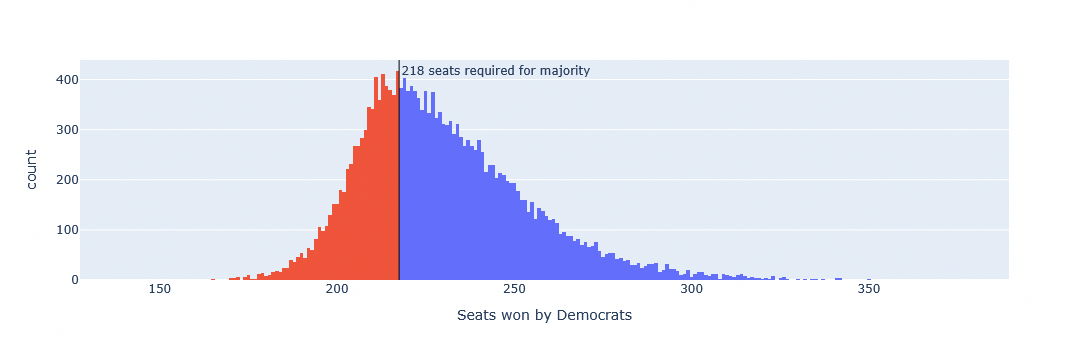

In [8]:
sims_hist = px.histogram(seat_sims, x='seats', nbins=np.unique(seat_sims['seats']).shape[0]*2, color='winner', 
                         labels={'seats':'Seats won by Democrats', 'winner': 'Winner'})
sims_hist.update_traces(showlegend=False)
sims_hist.add_vline(x=217.5, line_width=1, line_color='black', annotation_text='218 seats required for majority', 
                    annotation_position='top right')
sims_hist

In [9]:
# posterior prediction
post = pyreadr.read_r('model_output/labeled_posterior.RDS')[None]
post_untransp = post.copy()

In [10]:
post = post.T
post.head()

,0,1,2,3,4,5,6,7,8,9,...,19990,19991,19992,19993,19994,19995,19996,19997,19998,19999
AK-AL,-0.865247,-2.691407,-4.073042,-7.624856,-3.387877,-2.590288,-5.572118,-3.062785,-9.492944,0.635206,...,-0.137646,-4.957478,-5.635819,2.531666,2.253168,1.939938,-7.615138,-0.415860,-7.238090,-2.904484
AL-01,-13.195889,-11.700121,-13.756034,-16.930380,-14.454324,-14.203073,-20.042408,-11.276791,-15.912451,-9.690966,...,-11.106699,-14.404278,-14.963554,-12.161564,-11.957163,-13.517620,-20.901919,-10.387494,-16.661683,-12.682363
AL-02,2.900797,3.599404,-3.974715,-1.367424,-2.807681,-3.114499,-2.221439,-2.349161,-4.807300,0.973247,...,-2.482341,-2.474240,-5.254488,3.669417,4.060712,1.939023,-6.328301,2.124813,-5.813933,0.751592
AL-03,-17.191543,-17.160863,-22.329531,-20.884918,-23.092856,-19.027380,-23.227952,-19.000838,-25.713548,-17.260032,...,-17.945129,-23.043590,-21.629298,-19.661234,-16.438384,-18.166830,-22.654431,-20.065858,-24.457759,-22.239057
AL-04,-28.004791,-29.768618,-27.080995,-30.721933,-34.542790,-27.769705,-31.219692,-25.145665,-33.385546,-26.309883,...,-27.812732,-34.903876,-32.550437,-26.351713,-26.480048,-31.258765,-33.077954,-27.666118,-31.528423,-28.400905


In [11]:
sim_corr = post_untransp.corr()

In [12]:
sim_corr

,AK-AL,AL-01,AL-02,AL-03,AL-04,AL-05,AL-06,AL-07,AR-01,AR-02,...,WI-01,WI-03,WI-04,WI-05,WI-06,WI-07,WI-08,WV-01,WV-02,WY-AL
AK-AL,1.000000,0.725226,0.499296,0.742583,0.736546,0.729191,0.746331,0.513207,0.741506,0.749377,...,0.748717,0.553663,0.579767,0.740910,0.747320,0.710122,0.725863,0.741180,0.725856,0.708940
AL-01,0.725226,1.000000,0.506922,0.751598,0.743653,0.728464,0.750109,0.516570,0.749557,0.755305,...,0.744644,0.553346,0.586410,0.745418,0.753832,0.715409,0.729877,0.743263,0.727160,0.717327
AL-02,0.499296,0.506922,1.000000,0.514528,0.520418,0.508121,0.521621,0.709429,0.517090,0.517935,...,0.522013,0.564518,0.592322,0.520091,0.525638,0.659771,0.504480,0.521633,0.506869,0.657551
AL-03,0.742583,0.751598,0.514528,1.000000,0.762361,0.745656,0.769440,0.530212,0.763967,0.767784,...,0.765105,0.574600,0.595944,0.765551,0.767220,0.731654,0.746201,0.762493,0.746539,0.731278
AL-04,0.736546,0.743653,0.520418,0.762361,1.000000,0.739926,0.759235,0.531524,0.763144,0.764446,...,0.754302,0.567778,0.594181,0.754030,0.760917,0.726924,0.741035,0.756099,0.739263,0.726813
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
WI-07,0.710122,0.715409,0.659771,0.731654,0.726924,0.710742,0.735210,0.668981,0.731598,0.736209,...,0.732325,0.549792,0.573957,0.730376,0.739358,1.000000,0.711512,0.737398,0.715895,0.854211
WI-08,0.725863,0.729877,0.504480,0.746201,0.741035,0.728245,0.747437,0.510026,0.750051,0.752946,...,0.749966,0.566457,0.587692,0.753292,0.757009,0.711512,1.000000,0.747952,0.727753,0.713814
WV-01,0.741180,0.743263,0.521633,0.762493,0.756099,0.743543,0.765151,0.534087,0.765731,0.766258,...,0.763323,0.571818,0.600412,0.765138,0.766819,0.737398,0.747952,1.000000,0.750072,0.737407
WV-02,0.725856,0.727160,0.506869,0.746539,0.739263,0.727727,0.745362,0.514408,0.746965,0.750516,...,0.744548,0.562616,0.582461,0.744041,0.749289,0.715895,0.727753,0.750072,1.000000,0.714968


In [13]:
post.shape

(422, 20000)

In [14]:
def get_tipping_point(sim):
    """
    :param sim: Series representing one posterior draw or "simulation"
    :type sim: pd.Series
    """
    seats_won_dem = np.sum(sim > 0)
    if seats_won_dem >= 218 - dem_uncont.shape[0]: # Democrats win House in this draw
        sim = sim.sort_values(ascending=True)
        won_seats = sim[sim > 0]
        seat_margin = seats_won_dem - (218 - dem_uncont.shape[0])
    else: # Republicans win House in this draw
        sim = sim.sort_values(ascending=False)
        won_seats = sim[sim < 0]
        seat_margin = (435 - seats_won_dem) - (218 - rep_uncont.shape[0])
    return won_seats.iloc[seat_margin - 1], won_seats.index[seat_margin - 1]

In [15]:
tipping_points = np.array([]) # tipping point for *each sim*

for i in tqdm(range(post.shape[1])):
    sim = post.iloc[:, i]
    _, tp_seat = get_tipping_point(sim)
    tipping_points = np.append(tipping_points, tp_seat)

tipping_points

100%|███████████████████████████████████████████████████████████████████████████| 20000/20000 [00:31<00:00, 627.57it/s]


array(['CA-22', 'PA-08', 'TX-28', ..., 'CO-05', 'PA-08', 'PA-07'],
      shape=(20000,), dtype='<U32')

In [16]:
data = pd.read_csv('../../model_output/house_predictions.csv')
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,baseline,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-6.446531,-18.764506,-1,-37.529012,45.382471,3.649400,10.385,1,38.232975,52.518878
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-28.410209,-38.923019,0,-77.846039,35.901610,3.642474,0.000,2,28.764567,42.982672
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-6.579341,-19.716169,1,-39.432338,47.983200,3.554413,28.285,3,40.954235,54.895889
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-39.178110,-45.710827,-1,-91.421653,29.502220,3.511252,0.000,4,22.641726,36.429622
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-59.470205,-47.132870,-1,-94.265741,19.765018,3.572635,0.000,5,12.801361,26.685442


In [17]:
data['tipping_point_prob'] = data['cd'].map(lambda x: np.mean(tipping_points == x) * 100)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-18.764506,-1,-37.529012,45.382471,3.649400,10.385,1,38.232975,52.518878,0.160
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-38.923019,0,-77.846039,35.901610,3.642474,0.000,2,28.764567,42.982672,0.000
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-19.716169,1,-39.432338,47.983200,3.554413,28.285,3,40.954235,54.895889,1.285
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-45.710827,-1,-91.421653,29.502220,3.511252,0.000,4,22.641726,36.429622,0.000
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-47.132870,-1,-94.265741,19.765018,3.572635,0.000,5,12.801361,26.685442,0.000


In [18]:
data.sort_values('tipping_point_prob', ascending=False).head(10)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,dem_funds_2p_pct_offset,inc_dummy,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob
197,197,MI-10,Christina Hines,Mike Bouchard,False,False,MI,10,"HINES, CHRISTINA","BOUCHARD, MICHAEL",...,-3.195838,0,-6.391676,50.382204,3.718829,53.905,198,43.203842,57.759506,2.920
233,233,NC-11,Jamie Ager,Jennifer Balkcom,False,False,NC,11,"AGER, JAMIE",no_match,...,50.000000,0,100.000000,50.648848,3.737213,57.065,234,43.359965,57.978278,2.860
37,37,CA-22,Randy Villegas,David Valadao,False,True,CA,22,"VILLEGAS, RANDY","VALADAO, DAVID",...,12.732090,-1,25.464181,50.814913,3.529160,59.295,38,43.875495,57.699341,2.840
277,277,NY-17,Cait Conley,Mike Lawler,False,True,NY,17,"CONLEY, CAIT","LAWLER, MICHAEL VINCENT",...,3.773526,-1,7.547052,50.587124,3.571976,56.415,278,43.615999,57.566104,2.685
191,191,MI-04,Sean McCann,Bill Huizenga,False,True,MI,4,"MCCANN, SEAN","HUIZENGA, WILLIAM P",...,7.674047,-1,15.348095,50.046515,3.503731,50.570,192,43.204220,56.935165,2.660
187,187,ME-02,Matt Dunlap,Paul LePage,False,False,ME,2,"DUNLAP, MATT","LEPAGE, PAUL",...,-4.567471,0,-9.134942,49.627518,3.700258,45.950,188,42.426917,56.905436,2.620
98,98,FL-22,Pia Dandiya,Casey Askar,False,False,FL,22,"DANDIYA, PIA","ASKAR, CASEY",...,47.144568,0,94.289136,51.802662,3.705666,68.570,99,44.612301,59.052745,2.615
293,293,OH-07,Brian Poindexter,Max Miller,False,True,OH,7,"POINDEXTER, BRIAN","MILLER, MAX",...,-17.767963,-1,-35.535926,50.288773,3.605908,53.095,294,43.258449,57.359770,2.540
318,318,PA-07,Bob Brooks,Ryan Mackenzie,False,True,PA,7,"BROOKS, BOB","MACKENZIE, RYAN EDWARD",...,6.533790,-1,13.067581,50.134145,3.595461,51.295,319,43.050940,57.309275,2.515
390,390,VA-01,Shannon Taylor,Rob Wittman,False,True,VA,1,"TAYLOR, SHANNON LEIGH","WITTMAN, ROBERT J. MR.",...,3.919277,-1,7.838555,49.915055,3.519628,49.180,391,43.082414,56.762312,2.495


In [19]:
def get_rating(dem_chance):
    if dem_chance > 100:
        raise ValueError('Invalid win chance.')
    if dem_chance > 95:
        return 'Safe D'
    elif dem_chance >= 90:
        return 'Very Likely D'
    elif dem_chance >= 75:
        return 'Likely D'
    elif dem_chance >= 65:
        return 'Lean D'
    elif dem_chance >= 60:
        return 'Tilt D'
    elif dem_chance >= 40:
        return 'Tossup'
    elif dem_chance >= 35:
        return 'Tilt R'
    elif dem_chance >= 25:
        return 'Lean R'
    elif dem_chance >= 10:
        return 'Likely R'
    elif dem_chance >= 5:
        return 'Very Likely R'
    else:
        return 'Safe R'

def get_matchup(dem_cand, rep_cand):
    indie_d = ['Bill Hill']
    indie_r = ['Kevin Kiley']
    
    if dem_cand in indie_d:
        dem_lab = dem_cand + ' (I)'
        dem_color = 'purple'
    else:
        dem_lab = dem_cand + ' (D)'
        dem_color = 'blue'
    
    if rep_cand in indie_r:
        rep_lab = rep_cand + ' (I)'
        rep_color = 'purple'
    else:
        rep_lab = rep_cand + ' (R)'
        rep_color = 'red'

    return f'<p style="color:{dem_color};">' + dem_lab + f'</p> vs <p style="color:{rep_cand}">' + rep_lab + '</p>'

In [20]:
data['rating'] = data['chance'].map(lambda x: get_rating(x))
for party in ['dem', 'rep']:
    data[f'{party}_cand'] = data[f'{party}_cand'].map(lambda x: 'TBD' if x[:3] == 'TBD' else x)
data['matchup'] = data[['dem_cand', 'rep_cand']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand']), axis=1)
data.head()

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,funds_pct_margin,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,-37.529012,45.382471,3.649400,10.385,1,38.232975,52.518878,0.160,Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ..."
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,-77.846039,35.901610,3.642474,0.000,2,28.764567,42.982672,0.000,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>..."
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,-39.432338,47.983200,3.554413,28.285,3,40.954235,54.895889,1.285,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>..."
3,3,AL-03,Lee McInnis,Mike Rogers,False,True,AL,3,"MCINNIS, VICTOR LEE","ROGERS, MICHAEL",...,-91.421653,29.502220,3.511252,0.000,4,22.641726,36.429622,0.000,Safe R,"<p style=""color:blue;"">Lee McInnis (D)</p> vs ..."
4,4,AL-04,Amanda Pusczek,Robert Aderholt,False,True,AL,4,"PUSCZEK, AMANDA NOELLE","ADERHOLT, ROBERT B. REP.",...,-94.265741,19.765018,3.572635,0.000,5,12.801361,26.685442,0.000,Safe R,"<p style=""color:blue;"">Amanda Pusczek (D)</p> ..."


In [21]:
data['projected_winner'] = data['chance'].map(lambda x: '(D)' if x > 50 else '(R)')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,y_pred,y_pred_sd,chance,index,ci_low,ci_hi,tipping_point_prob,rating,matchup,projected_winner
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,45.382471,3.649400,10.385,1,38.232975,52.518878,0.160,Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R)
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,35.901610,3.642474,0.000,2,28.764567,42.982672,0.000,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R)
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,47.983200,3.554413,28.285,3,40.954235,54.895889,1.285,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>...",(R)


In [22]:
pvi_24 = pd.read_csv('../../transformed/pvi/past_pres_results_by24dist.csv')
data = pd.merge(left=data, right=pvi_24[['district', 'party']], left_on='cd', right_on='district')
data = data.rename({'party': 'curr_party'}, axis=1)
data['hold'] = data['projected_winner'] ==  data['curr_party']
data['flip'] = data['hold'].map(lambda x: not x)
data['flip_indic'] = data['flip'].map(lambda x: 'Flip' if x else '')
#data['flip'] = data['flip'].map(lambda x: 'Yes' if x else 'No')
data.head(2)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,ci_hi,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,52.518878,0.16,Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R),AK-AL,(R),True,False,
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,42.982672,0.00,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R),AL-01,(R),True,False,


In [23]:
data['projected_2p_margin'] = data['y_pred'].map(lambda y_pred: f'D+{y_pred - (100-y_pred):.1f}' if y_pred > 50 else f'R+{(100-y_pred) - y_pred:.1f}')
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,tipping_point_prob,rating,matchup,projected_winner,district_y,curr_party,hold,flip,flip_indic,projected_2p_margin
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,0.160,Likely R,"<p style=""color:purple;"">Bill Hill (I)</p> vs ...",(R),AK-AL,(R),True,False,,R+9.2
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,0.000,Safe R,"<p style=""color:blue;"">Clyde Jones Jr. (D)</p>...",(R),AL-01,(R),True,False,,R+28.2
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,1.285,Lean R,"<p style=""color:blue;"">Shomari Figures (D)</p>...",(R),AL-02,(D),False,True,Flip,R+4.0


In [24]:
data['rep_chance'] = data['chance'].map(lambda x: 100 - x)
data['rounded_dem_chance'] = data['chance'].map(lambda x: np.round(x, 1))
data['rounded_rep_chance'] = data['rep_chance'].map(lambda x: np.round(x, 1))
data['disp_dem_chance'] = data['rounded_dem_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data['disp_rep_chance'] = data['rounded_rep_chance'].map(lambda x: '>99%' if x > 99 else ('<1%' if x < 1 else str(x) + '%'))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,curr_party,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,(R),True,False,,R+9.2,89.615,10.4,89.6,10.4%,89.6%
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,(R),True,False,,R+28.2,100.000,0.0,100.0,<1%,>99%
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,(D),False,True,Flip,R+4.0,71.715,28.3,71.7,28.3%,71.7%


In [25]:
data['swing_24_to_26'] = data['y_pred'].astype(float).map(lambda x: x - (100 - x)) - data['dem_2p_24'].astype(float).map(lambda x: x - (100 - x))
data.head(3)

,...1,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fec_dem_fuzzymatch,fec_rep_fuzzymatch,...,hold,flip,flip_indic,projected_2p_margin,rep_chance,rounded_dem_chance,rounded_rep_chance,disp_dem_chance,disp_rep_chance,swing_24_to_26
0,0,AK-AL,Bill Hill,Nick Begich,False,True,AK,0,"HILL, BILL","BEGICH, NICHOLAS III",...,True,False,,R+9.2,89.615,10.4,89.6,10.4%,89.6%,4.458067
1,1,AL-01,Clyde Jones Jr.,Jerry Carl,False,False,AL,1,"JONES, CLYDE W MR. JR","CARL, JERRY LEE, JR",...,True,False,,R+28.2,100.000,0.0,100.0,<1%,>99%,8.147693
2,2,AL-02,Shomari Figures,Rhett Marques,True,False,AL,2,"FIGURES, SHOMARI C.","MARQUES, RHETT",...,False,True,Flip,R+4.0,71.715,28.3,71.7,28.3%,71.7%,10.430828


In [26]:
data['geoid']

0       200
1       101
2       102
3       103
4       104
       ... 
417    5507
418    5508
419    5401
420    5402
421    5600
Name: geoid, Length: 422, dtype: int64

In [27]:
dem_uclen = dem_uncont.shape[0]
dem_uncont['rating'] = np.full(dem_uclen, 'Safe D')
dem_uncont['chance'] = np.full(dem_uclen, 100)
dem_uncont['y_pred'] = np.full(dem_uclen, 100)
dem_uncont['swing_24_to_26'] = np.full(dem_uclen, float('nan')) # Placeholder
dem_uncont['disp_dem_chance'] = np.full(dem_uclen, '100%')
dem_uncont['disp_rep_chance'] = np.full(dem_uclen, '0%')
dem_uncont['projected_2p_margin'] = np.full(dem_uclen, 'D+100')
dem_uncont['flip_indic'] = np.full(dem_uclen, '')
dem_uncont = dem_uncont.drop(['Unnamed: 0'], axis=1)
dem_uncont['matchup'] = dem_uncont[['dem_cand', 'rep_cand']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand']), axis=1)
dem_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-04,Mike Thompson/Eric Jones,Not Contested,True,False,CA,4,6,604,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Mike Thompson/Eric Jone..."
1,CA-07,Doris Matsui/Mai Vang,Not Contested,True,False,CA,7,6,607,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Doris Matsui/Mai Vang (..."
2,CA-11,Scott Weiner/Connie Chan,Not Contested,False,False,CA,11,6,611,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Scott Weiner/Connie Cha..."
3,CA-12,Lateefah Simon,Not Contested,True,False,CA,12,6,612,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Lateefah Simon (D)</p> ..."
4,CA-14,Aisha Wahab/Melissa Hernandez,Not Contested,False,False,CA,14,6,614,Safe D,100,100,NaN,100%,0%,D+100,,"<p style=""color:blue;"">Aisha Wahab/Melissa Her..."


In [28]:
rep_uclen = rep_uncont.shape[0]
rep_uncont['rating'] = np.full(rep_uclen, 'Safe R')
rep_uncont['chance'] = np.full(rep_uclen, 0)
rep_uncont['y_pred'] = np.full(rep_uclen, 0)
rep_uncont['swing_24_to_26'] = np.full(rep_uclen, float('nan')) # Placeholder
rep_uncont['disp_dem_chance'] = np.full(rep_uclen, '0%')
rep_uncont['disp_rep_chance'] = np.full(rep_uclen, '100%')
rep_uncont['projected_2p_margin'] = np.full(rep_uclen, 'R+100')
rep_uncont['flip_indic'] = np.full(rep_uclen, '')
rep_uncont = rep_uncont.drop(['Unnamed: 0'], axis=1)
rep_uncont['matchup'] = rep_uncont[['dem_cand', 'rep_cand']].apply(lambda x: get_matchup(x['dem_cand'], x['rep_cand']), axis=1)
rep_uncont.head()

,cd,dem_cand,rep_cand,dem_inc_any,rep_inc_any,state_po,district_number,fips,geoid,rating,chance,y_pred,swing_24_to_26,disp_dem_chance,disp_rep_chance,projected_2p_margin,flip_indic,matchup
0,CA-40,Not Contested,Young Kim/Ken Calvert,False,True,CA,40,6,640,Safe R,0,0,NaN,0%,100%,R+100,,"<p style=""color:blue;"">Not Contested (D)</p> v..."


In [29]:
incl_cols = ['cd', 'dem_cand', 'rep_cand', 'dem_inc_any', 'rep_inc_any', 'rating', 'chance', 'disp_dem_chance',
            'disp_rep_chance', 'projected_2p_margin', 'y_pred', 'flip_indic', 'geoid', 'matchup', 'swing_24_to_26']
disp_data = pd.concat([data[incl_cols], dem_uncont[incl_cols], rep_uncont[incl_cols]], axis=0)
disp_data.shape

(435, 15)

In [36]:
tab_data = data[['cd', 'dem_cand', 'rep_cand', 'rating', 'disp_dem_chance', 'disp_rep_chance', 'projected_2p_margin', 'tipping_point_prob']]
for party in ['dem', 'rep']:
    tab_data[f'disp_{party}_chance'] = tab_data[f'disp_{party}_chance'].map(lambda x: f'<p style="color:{'blue' if party == 'dem' else 'red'};">{x}</p>')
    tab_data[f'{party}_cand'] = tab_data[f'{party}_cand'].map(lambda x: f'{x} (Ind)' if x in ['Bill Hill', 'Kevin Kiley'] else x)
tab_data = tab_data.rename({
    'cd': 'District',
    'dem_cand': 'Democrat',
    'rep_cand': 'Republican',
    'rating': 'Rating',
    'disp_dem_chance': 'Dem Chance',
    'disp_rep_chance': 'Rep Chance',
    'projected_2p_margin': 'Projected Margin',
    'tipping_point_prob': 'Tipping Point Chance'
}, axis=1)
tab_data.head()

,District,Democrat,Republican,Rating,Dem Chance,Rep Chance,Projected Margin,Tipping Point Chance
0,AK-AL,Bill Hill (Ind),Nick Begich,Likely R,"<p style=""color:blue;"">10.4%</p>","<p style=""color:red;"">89.6%</p>",R+9.2,0.160
1,AL-01,Clyde Jones Jr.,Jerry Carl,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+28.2,0.000
2,AL-02,Shomari Figures,Rhett Marques,Lean R,"<p style=""color:blue;"">28.3%</p>","<p style=""color:red;"">71.7%</p>",R+4.0,1.285
3,AL-03,Lee McInnis,Mike Rogers,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+41.0,0.000
4,AL-04,Amanda Pusczek,Robert Aderholt,Safe R,"<p style=""color:blue;""><1%</p>","<p style=""color:red;"">>99%</p>",R+60.5,0.000


In [37]:
disp_data.to_csv('display_data/choropleth_display_data.csv')
tab_data.to_csv('display_data/table_display_data.csv')